# CLIP Pipeline — Full Notebook with Hard Negative Mining

## Variants we ran

The headline numbers in `report.md` are the **mean ± std over four independent training runs** with different seeds. We also ran a freezing-strategy ablation (last-2-blocks instead of the headline's last-4-blocks). Every variant uses the same code below — only two constants in **Cell 2 — Imports & Paths** are changed:

| Variant | `SEED` (line: `FT_SEED = SEEDS[0]`) | `LAST_N_BLOCKS` | Checkpoint saved as | Result file |
| --- | --- | --- | --- | --- |
| Headline run | 83 | 4 | `clip_finetuned_hn.pt` | `eval_C_alpha0.7_hn.json` |
| Seed 527 | 527 | 4 | `clip_finetuned_hn_seed527.pt` | `eval_C_alpha0.7_hn_seed527.json` |
| Seed 33  | 33 | 4 | `clip_finetuned_hn_seed33.pt` | `eval_C_alpha0.7_hn_seed33.json` |
| Seed 588 | 588 | 4 | `clip_finetuned_hn_seed588.pt` | (Kaggle output) |
| Last-2-blocks ablation | 83 | **2** | `clip_finetuned_hn_l2blocks.pt` | `eval_C_alpha0.7_hn_l2blocks.json` |

**To reproduce a specific variant:** open Cell 2 (Imports & Paths), change `FT_SEED` and/or `LAST_N_BLOCKS` to match the row, and run the notebook end-to-end. Each full run takes ~1 hour on a T4 / 4060.

**To run all four seeds end-to-end:** wrap the notebook in a shell loop calling `train_hn.py` with `--seed N --suffix _seedN` — that script is the CLI-friendly version of this notebook (kept in the dev tree, not in this exhibit). The `taralsanka/clip-saved-outputs` and `ashok1145/clip-hn-checkpoint` Kaggle datasets host the resulting `.pt` files so you can skip retraining and go straight to `demo_batch_eval.py`.

## Cell 1 — Install

In [1]:
!pip install open-clip-torch hnswlib tqdm ultralytics --quiet

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00


## Cell 2 — Imports & Paths

In [2]:
import json, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from collections import defaultdict
import open_clip
import hnswlib
import matplotlib.pyplot as plt

# ── Paths ──
DATASET_ROOT  = Path("/kaggle/input/datasets/ashok1145/vr-fproj/vr_final_proj_dataset")
IMG_ROOT      = DATASET_ROOT / "img" / "img"
SPLIT_FILE    = DATASET_ROOT / "eval" / "list_eval_partition.txt"
BBOX_FILE     = DATASET_ROOT / "Anno" / "list_bbox_inshop.txt"
CAPTIONS_FILE = Path("/kaggle/input/datasets/taralsanka/blip-updated-captions/captions.json")
YOLO_PT       = Path("/kaggle/input/models/taralsanka/best-yolo-8l-upd/other/default/1/best_yolo8l.pt")
OUTPUT_DIR    = Path("/kaggle/working")
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Config ──
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"
CLIP_MODEL    = "ViT-L-14"
CLIP_PRETRAIN = "openai"
EMB_DIM       = 768
PAD           = 0.05
BATCH_SIZE    = 64
TOP_K_LIST    = [5, 10, 15]
SEEDS         = [83, 588, 527, 33]   # same seeds as original run
ALPHA_VALUES  = [0.7, 0.5]           # ablation B & C alpha values

print(f"Device : {DEVICE}")
print(f"IMG_ROOT exists    : {IMG_ROOT.exists()}")
print(f"Captions exists    : {CAPTIONS_FILE.exists()}")
print(f"YOLO pt exists     : {YOLO_PT.exists()}")

Device : cuda
IMG_ROOT exists    : True
Captions exists    : True
YOLO pt exists     : False


## Cell 3 — Helpers

In [3]:
def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

def parse_split_file(path):
    with open(path) as f: lines = f.readlines()
    rows = []
    for line in lines[2:]:
        parts = line.strip().split()
        if len(parts) < 3: continue
        raw = parts[0]
        img_name = raw[len("img/"):] if raw.startswith("img/") else raw
        rows.append({"image_name": img_name, "item_id": parts[1], "split": parts[2]})
    return rows

def parse_bbox_file(path):
    with open(path) as f: lines = f.readlines()
    bboxes = {}
    for line in lines[2:]:
        parts = line.strip().split()
        if len(parts) < 7: continue
        raw = parts[0]
        img_name = raw[len("img/"):] if raw.startswith("img/") else raw
        bboxes[img_name] = (int(parts[3]), int(parts[4]), int(parts[5]), int(parts[6]))
    return bboxes

def bbox_crop(img_path, bbox, pad=PAD):
    pil = Image.open(img_path).convert("RGB")
    W, H = pil.size
    x1, y1, x2, y2 = bbox
    px = int((x2-x1)*pad); py = int((y2-y1)*pad)
    x1=max(0,x1-px); y1=max(0,y1-py); x2=min(W,x2+px); y2=min(H,y2+py)
    return pil.crop((x1,y1,x2,y2)) if x2>x1 and y2>y1 else pil

# ── Load annotations once ──
all_rows     = parse_split_file(SPLIT_FILE)
bbox_map     = parse_bbox_file(BBOX_FILE)
captions     = json.load(open(CAPTIONS_FILE))
train_rows   = [r for r in all_rows if r["split"] == "train"]
gallery_rows = [r for r in all_rows if r["split"] == "gallery"]
query_rows   = [r for r in all_rows if r["split"] == "query"]

print(f"Train  : {len(train_rows)}")
print(f"Gallery: {len(gallery_rows)}")
print(f"Query  : {len(query_rows)}")
print(f"Captions loaded: {len(captions)}")

Train  : 25882
Gallery: 12612
Query  : 14218
Captions loaded: 38494


## Cell 4 — Load CLIP (frozen) for hard negative mining pass

In [4]:
clip_frozen, _, clip_preprocess = open_clip.create_model_and_transforms(
    CLIP_MODEL, pretrained=CLIP_PRETRAIN
)
tokenizer   = open_clip.get_tokenizer(CLIP_MODEL)
clip_frozen = clip_frozen.to(DEVICE).eval()
print(f"Frozen CLIP loaded: {CLIP_MODEL}")

open_clip_model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Frozen CLIP loaded: ViT-L-14


## Cell 5 — Build hard negative pool

Single frozen-CLIP pass over all train images → HNSW index → for each image find
the K nearest neighbors that belong to a **different** item_id.  
Done once before training; refreshed every 3 epochs using the current model.

In [5]:
HN_POOL_SIZE = 10    # hard negatives stored per image
HN_EMB_BATCH = 128
FETCH_K      = HN_POOL_SIZE * 5 + 1

@torch.no_grad()
def embed_rows(rows, model, preprocess, batch_size=HN_EMB_BATCH):
    """Embed a list of image rows. Returns (embs, item_ids, img_names)."""
    model.eval()
    all_embs, all_ids, all_names = [], [], []
    for i in tqdm(range(0, len(rows), batch_size), desc="Embedding", leave=False):
        batch = rows[i:i+batch_size]
        crops, ids, names = [], [], []
        for r in batch:
            p = IMG_ROOT / r["image_name"]
            if not p.exists(): continue
            try:
                bbox = bbox_map.get(r["image_name"])
                crop = bbox_crop(p, bbox) if bbox else Image.open(p).convert("RGB")
                crops.append(preprocess(crop))
                ids.append(r["item_id"])
                names.append(r["image_name"])
            except Exception:
                continue
        if not crops: continue
        t   = torch.stack(crops).to(DEVICE)
        emb = F.normalize(model.encode_image(t).float(), dim=-1)
        all_embs.append(emb.cpu().numpy())
        all_ids.extend(ids); all_names.extend(names)
    return np.vstack(all_embs).astype(np.float32), all_ids, all_names


def build_hn_pool(embs, ids, names):
    """Mine hard negatives from an embedding array. Returns dict img_name -> [hn_names]."""
    id_arr = np.array(ids)
    idx    = hnswlib.Index(space='cosine', dim=EMB_DIM)
    idx.init_index(max_elements=len(embs), ef_construction=200, M=32)
    idx.add_items(embs, list(range(len(embs))))
    idx.set_ef(100)
    labels, _ = idx.knn_query(embs, k=FETCH_K)
    pool = {}
    for i, name in enumerate(names):
        hard_negs = []
        for pos in labels[i]:
            if pos == i or id_arr[pos] == ids[i]: continue
            hard_negs.append(names[pos])
            if len(hard_negs) == HN_POOL_SIZE: break
        pool[name] = hard_negs
    return pool


print("Step 1: Embedding train images with frozen CLIP...")
train_embs, train_ids, train_names = embed_rows(train_rows, clip_frozen, clip_preprocess)
print(f"  Embedded {len(train_names)} train images")

print("Step 2: Mining initial hard negative pool...")
hard_neg_pool = build_hn_pool(train_embs, train_ids, train_names)
sizes = [len(v) for v in hard_neg_pool.values()]
print(f"  Pool built. Avg per image: {np.mean(sizes):.1f}  Min: {min(sizes)}  Max: {max(sizes)}")

Step 1: Embedding train images with frozen CLIP...


  Embedded 25882 train images
Step 2: Mining initial hard negative pool...
  Pool built. Avg per image: 10.0  Min: 6  Max: 10


## Cell 6 — Triplet Dataset

In [6]:
class HardNegTripletDataset(Dataset):
    """
    Returns (anchor, positive, hard_negative) crops.
    Anchor + positive share item_id. Hard negative is nearest different-item neighbor.
    """
    def __init__(self, rows, hard_neg_pool, transform):
        groups = defaultdict(list)
        for r in rows:
            groups[r["item_id"]].append(r["image_name"])
        self.items = [
            (iid, imgs) for iid, imgs in groups.items()
            if len(imgs) >= 2 and any(hard_neg_pool.get(n) for n in imgs)
        ]
        self.hard_neg_pool = hard_neg_pool
        self.transform     = transform

    def __len__(self): return len(self.items)

    def _load(self, name):
        p    = IMG_ROOT / name
        bbox = bbox_map.get(name)
        crop = bbox_crop(p, bbox) if bbox else Image.open(p).convert("RGB")
        return self.transform(crop)

    def __getitem__(self, idx):
        item_id, imgs = self.items[idx]
        anc_name, pos_name = random.sample(imgs, 2)
        hn_pool = self.hard_neg_pool.get(anc_name) or self.hard_neg_pool.get(pos_name) or []
        try:
            anchor   = self._load(anc_name)
            positive = self._load(pos_name)
            hard_neg = self._load(random.choice(hn_pool)) if hn_pool else anchor
        except Exception:
            anchor = positive = hard_neg = self._load(anc_name)
        return anchor, positive, hard_neg


hn_dataset = HardNegTripletDataset(train_rows, hard_neg_pool, clip_preprocess)
print(f"Triplet dataset: {len(hn_dataset)} unique items")

Triplet dataset: 3985 unique items


## Cell 7 — Fine-tune CLIP with hard negative loss

$$\mathcal{L} = \mathcal{L}_{\text{InfoNCE}}(a,p) + \lambda \cdot \mathcal{L}_{\text{Triplet}}(a,p,n)$$

LR schedule: linear warmup (epoch 1) → cosine annealing

In [7]:
# ── Hyperparameters ──
FT_EPOCHS          = 10
FT_BATCH_SIZE      = 32     # reduce to 16 if GPU OOM
FT_LR              = 1e-5
WEIGHT_DECAY       = 0.01
TEMPERATURE        = 0.07
TRIPLET_MARGIN     = 0.3
LAMBDA_TRIPLET     = 0.5
LAST_N_BLOCKS      = 4
WARMUP_EPOCHS      = 1
REFRESH_POOL_EVERY = 3      # re-mine pool every N epochs with updated model
FT_SEED            = SEEDS[0]

set_seed(FT_SEED)

# ── Fresh CLIP for fine-tuning ──
clip_model, _, _ = open_clip.create_model_and_transforms(CLIP_MODEL, pretrained=CLIP_PRETRAIN)
clip_model       = clip_model.to(DEVICE)

# Freeze all → unfreeze last N blocks + projection
for p in clip_model.parameters(): p.requires_grad = False
for block in list(clip_model.visual.transformer.resblocks)[-LAST_N_BLOCKS:]:
    for p in block.parameters(): p.requires_grad = True
for p in clip_model.visual.ln_post.parameters(): p.requires_grad = True
if hasattr(clip_model.visual, 'proj') and clip_model.visual.proj is not None:
    clip_model.visual.proj.requires_grad = True

trainable = sum(p.numel() for p in clip_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in clip_model.parameters())
print(f"Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

# ── Loss functions ──
def infonce_loss(z1, z2, temp=TEMPERATURE):
    B   = z1.shape[0]
    z   = torch.cat([z1, z2], dim=0)
    sim = (z @ z.T) / temp
    sim.masked_fill_(torch.eye(2*B, dtype=torch.bool, device=z.device), float('-inf'))
    labels = torch.cat([torch.arange(B, 2*B), torch.arange(0, B)]).to(z.device)
    return F.cross_entropy(sim, labels)

triplet_loss_fn = nn.TripletMarginWithDistanceLoss(
    distance_function=lambda a, b: 1.0 - F.cosine_similarity(a, b),
    margin=TRIPLET_MARGIN, reduction='mean'
)

# ── DataLoader ──
ft_loader = DataLoader(
    hn_dataset, batch_size=FT_BATCH_SIZE, shuffle=True,
    num_workers=4, pin_memory=True, drop_last=True
)

# ── Optimizer + LR schedule ──
optimizer       = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, clip_model.parameters()),
    lr=FT_LR, weight_decay=WEIGHT_DECAY
)
steps_per_epoch = len(ft_loader)
total_steps     = FT_EPOCHS * steps_per_epoch
warmup_steps    = WARMUP_EPOCHS * steps_per_epoch

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler    = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

# ── Pool refresh helper ──
def refresh_pool(model):
    print("  Refreshing hard negative pool...")
    embs, ids, names = embed_rows(train_rows, model, clip_preprocess)
    new_pool = build_hn_pool(embs, ids, names)
    hn_dataset.hard_neg_pool = new_pool
    print("  Pool refreshed.")

# ── Training loop ──
clip_model.train()
best_loss = float('inf')
history   = []

for epoch in range(FT_EPOCHS):
    if epoch > 0 and epoch % REFRESH_POOL_EVERY == 0:
        refresh_pool(clip_model)

    tot_loss = tot_nce = tot_tri = 0.0
    for anchor, positive, hard_neg in tqdm(ft_loader, desc=f"Epoch {epoch+1}/{FT_EPOCHS}", leave=False):
        anchor   = anchor.to(DEVICE)
        positive = positive.to(DEVICE)
        hard_neg = hard_neg.to(DEVICE)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
            z_a = F.normalize(clip_model.encode_image(anchor).float(),   dim=-1)
            z_p = F.normalize(clip_model.encode_image(positive).float(), dim=-1)
            z_n = F.normalize(clip_model.encode_image(hard_neg).float(), dim=-1)
            loss_nce = infonce_loss(z_a, z_p)
            loss_tri = triplet_loss_fn(z_a, z_p, z_n)
            loss     = loss_nce + LAMBDA_TRIPLET * loss_tri

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            filter(lambda p: p.requires_grad, clip_model.parameters()), 1.0
        )
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        tot_loss += loss.item()
        tot_nce  += loss_nce.item()
        tot_tri  += loss_tri.item()

    n   = len(ft_loader)
    avg = tot_loss/n; avg_nce = tot_nce/n; avg_tri = tot_tri/n
    lr  = scheduler.get_last_lr()[0]
    history.append({"epoch": epoch+1, "loss": avg, "infonce": avg_nce, "triplet": avg_tri, "lr": lr})
    print(f"Epoch {epoch+1:2d}/{FT_EPOCHS} | Total: {avg:.4f} | InfoNCE: {avg_nce:.4f} | Triplet: {avg_tri:.4f} | LR: {lr:.2e}")

    if avg < best_loss:
        best_loss = avg
        torch.save(clip_model.state_dict(), OUTPUT_DIR / "clip_finetuned_hn.pt")
        print(f"  ✓ Best model saved (loss={best_loss:.4f})")

json.dump(history, open(OUTPUT_DIR / "training_history_hn.json", "w"), indent=2)
print(f"\nTraining done. Best loss: {best_loss:.4f}")
print(f"Saved → clip_finetuned_hn.pt")

/tmp/ipykernel_23/806617483.py:68: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))


Trainable: 51,173,376 / 427,616,513 (12.0%)


Epoch 1/10:   0%|          | 0/124 [00:00<?, ?it/s]/tmp/ipykernel_23/806617483.py:94: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
/tmp/ipykernel_23/806617483.py:109: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch  1/10 | Total: 2.0526 | InfoNCE: 1.8891 | Triplet: 0.3270 | LR: 1.00e-05
  ✓ Best model saved (loss=2.0526)


Epoch  2/10 | Total: 0.8103 | InfoNCE: 0.6947 | Triplet: 0.2313 | LR: 9.70e-06
  ✓ Best model saved (loss=0.8103)


...

Epoch  7/10 | Total: 0.4387 | InfoNCE: 0.3059 | Triplet: 0.2656 | LR: 2.50e-06
  ✓ Best model saved (loss=0.4387)


Epoch  8/10 | Total: 0.4095 | InfoNCE: 0.2783 | Triplet: 0.2624 | LR: 1.17e-06
  ✓ Best model saved (loss=0.4095)


Epoch  9/10 | Total: 0.4028 | InfoNCE: 0.2729 | Triplet: 0.2599 | LR: 3.02e-07
  ✓ Best model saved (loss=0.4028)
  Refreshing hard negative pool...


  Pool refreshed.


Epoch 10/10 | Total: 0.4012 | InfoNCE: 0.2706 | Triplet: 0.2610 | LR: 0.00e+00
  ✓ Best model saved (loss=0.4012)

Training done. Best loss: 0.4012
Saved → clip_finetuned_hn.pt


## Cell 8 — Training curves

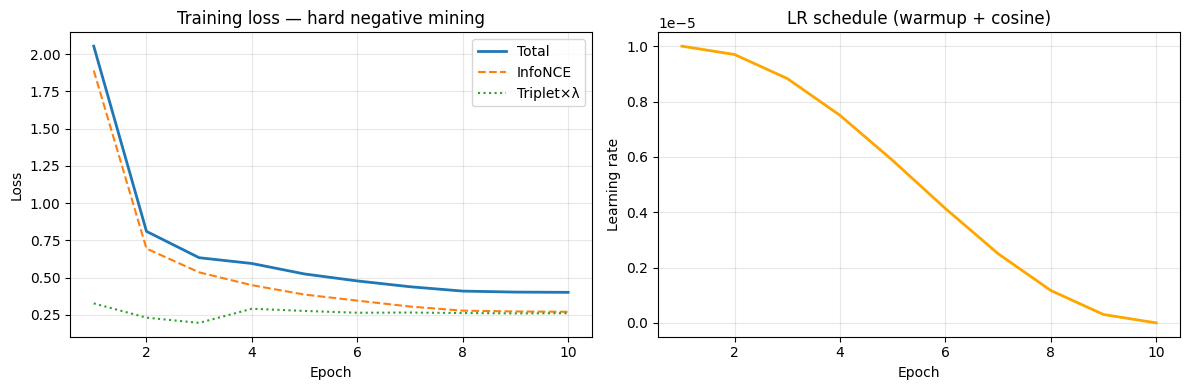

In [8]:
epochs   = [h["epoch"]   for h in history]
losses   = [h["loss"]    for h in history]
infoncs  = [h["infonce"] for h in history]
triplets = [h["triplet"] for h in history]
lrs      = [h["lr"]      for h in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, losses,   label="Total",     linewidth=2)
axes[0].plot(epochs, infoncs,  label="InfoNCE",    linestyle="--")
axes[0].plot(epochs, triplets, label="Triplet×λ",  linestyle=":")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Training loss — hard negative mining")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, lrs, color="orange", linewidth=2)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Learning rate")
axes[1].set_title("LR schedule (warmup + cosine)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves_hn.png", dpi=120)
plt.show()

## Cell 9 — Embedding generation helper

$$v_i = \alpha \cdot \phi_V(\hat{x}_i) + (1-\alpha) \cdot \phi_T(c_i), \quad \|v_i\|=1$$

In [9]:
@torch.no_grad()
def generate_embeddings(rows, model, alpha, batch_size=BATCH_SIZE):
    model.eval()
    all_embs, all_ids, all_names = [], [], []
    for i in tqdm(range(0, len(rows), batch_size), desc=f"Embed α={alpha}", leave=False):
        batch = rows[i:i+batch_size]
        crops, texts, ids, names = [], [], [], []
        for r in batch:
            p = IMG_ROOT / r["image_name"]
            if not p.exists(): continue
            try:
                bbox = bbox_map.get(r["image_name"])
                crop = bbox_crop(p, bbox) if bbox else Image.open(p).convert("RGB")
                crops.append(clip_preprocess(crop))
                texts.append(captions.get(r["image_name"], ""))
                ids.append(r["item_id"])
                names.append(r["image_name"])
            except Exception:
                continue
        if not crops: continue
        img_t = torch.stack(crops).to(DEVICE)
        txt_t = tokenizer(texts).to(DEVICE)
        ie = F.normalize(model.encode_image(img_t).float(), dim=-1)
        te = F.normalize(model.encode_text(txt_t).float(),  dim=-1)
        if   alpha == 1.0: fused = ie
        elif alpha == 0.0: fused = te
        else:              fused = alpha * ie + (1.0 - alpha) * te
        fused = F.normalize(fused, dim=-1)
        all_embs.append(fused.cpu().numpy())
        all_ids.extend(ids); all_names.extend(names)
    return np.vstack(all_embs).astype(np.float32), all_ids, all_names


def build_hnsw(embeddings):
    idx = hnswlib.Index(space='cosine', dim=EMB_DIM)
    idx.init_index(max_elements=len(embeddings), ef_construction=200, M=32)
    idx.add_items(embeddings, list(range(len(embeddings))))
    idx.set_ef(150)
    return idx

print("Helpers defined.")

Helpers defined.


## Cell 10 — Fixed evaluation metrics

In [10]:
def recall_at_k(ret, qid, k):
    return int(any(i == qid for i in ret[:k]))

def ndcg_at_k(ret, qid, n_rel, k):
    dcg  = sum(1/np.log2(r+2) for r,i in enumerate(ret[:k]) if i == qid)
    idcg = sum(1/np.log2(r+2) for r in range(min(n_rel, k)))
    return dcg/idcg if idcg > 0 else 0.0

def ap_at_k(ret, qid, n_rel, k):
    hits = prec = 0
    for r, i in enumerate(ret[:k], 1):
        if i == qid: hits += 1; prec += hits/r
    denom = min(n_rel, k)
    return prec/denom if denom > 0 else 0.0

def evaluate(qry_embs, qry_ids, gal_ids, index, k_list=TOP_K_LIST):
    gal_cnt  = defaultdict(int)
    for iid in gal_ids: gal_cnt[iid] += 1
    gal_arr  = np.array(gal_ids)
    max_k    = max(k_list)
    pq       = {f"{m}@{k}": [] for m in ["Recall","NDCG","mAP"] for k in k_list}
    labels,_ = index.knn_query(qry_embs, k=max_k)
    for qi, qid in enumerate(qry_ids):
        ret   = gal_arr[labels[qi]].tolist()
        n_rel = gal_cnt.get(qid, 0)
        for k in k_list:
            pq[f"Recall@{k}"].append(recall_at_k(ret, qid, k))
            pq[f"NDCG@{k}"].append(ndcg_at_k(ret, qid, n_rel, k))
            pq[f"mAP@{k}"].append(ap_at_k(ret, qid, n_rel, k))
    return {m: float(np.mean(v)) for m, v in pq.items()}

print("Metrics defined.")

Metrics defined.


## Cell 11 — Ablation A: Vision-only frozen CLIP (α=1)

In [11]:
all_results = {}
seed_res_A  = []

for seed in SEEDS:
    set_seed(seed)
    gal_embs, gal_ids, gal_names = generate_embeddings(gallery_rows, clip_frozen, alpha=1.0)
    qry_embs, qry_ids, _         = generate_embeddings(query_rows,   clip_frozen, alpha=1.0)
    idx_A = build_hnsw(gal_embs)
    m     = evaluate(qry_embs, qry_ids, gal_ids, idx_A)
    seed_res_A.append(m)
    print(f"[A] Seed {seed}: R@10={m['Recall@10']:.4f}  mAP@10={m['mAP@10']:.4f}")

res_A = {k: {"mean": float(np.mean([r[k] for r in seed_res_A])),
             "std":  float(np.std( [r[k] for r in seed_res_A]))} for k in seed_res_A[0]}
all_results["A_vision_only_alpha1"] = res_A

# Save index (last seed)
idx_A.save_index(str(OUTPUT_DIR / "gallery_index_A.bin"))
json.dump({"item_ids": gal_ids, "img_names": gal_names}, open(OUTPUT_DIR/"gallery_meta_A.json","w"))
print("\nAblation A done. Index saved.")

[A] Seed 83: R@10=0.5771  mAP@10=0.1837


[A] Seed 588: R@10=0.5770  mAP@10=0.1837


[A] Seed 527: R@10=0.5771  mAP@10=0.1837


[A] Seed 33: R@10=0.5771  mAP@10=0.1837

Ablation A done. Index saved.


## Cell 12 — Ablation B: Frozen CLIP + BLIP captions (two α values)

In [12]:
for alpha in ALPHA_VALUES:
    seed_res_B = []
    for seed in SEEDS:
        set_seed(seed)
        gal_embs, gal_ids, gal_names = generate_embeddings(gallery_rows, clip_frozen, alpha=alpha)
        qry_embs, qry_ids, _         = generate_embeddings(query_rows,   clip_frozen, alpha=alpha)
        idx_B = build_hnsw(gal_embs)
        m     = evaluate(qry_embs, qry_ids, gal_ids, idx_B)
        seed_res_B.append(m)
        print(f"[B α={alpha}] Seed {seed}: R@10={m['Recall@10']:.4f}  mAP@10={m['mAP@10']:.4f}")

    key = f"B_frozen_alpha{str(alpha).replace('.','')}"
    all_results[key] = {k: {"mean": float(np.mean([r[k] for r in seed_res_B])),
                            "std":  float(np.std( [r[k] for r in seed_res_B]))} for k in seed_res_B[0]}
    idx_B.save_index(str(OUTPUT_DIR / f"gallery_index_B_alpha{str(alpha).replace('.','')}.bin"))
    json.dump({"item_ids": gal_ids, "img_names": gal_names},
              open(OUTPUT_DIR / f"gallery_meta_B_alpha{str(alpha).replace('.','')}.json", "w"))
    print(f"  Ablation B α={alpha} done. Index saved.\n")

[B α=0.7] Seed 83: R@10=0.4096  mAP@10=0.0939


[B α=0.7] Seed 588: R@10=0.4097  mAP@10=0.0938


[B α=0.7] Seed 527: R@10=0.4096  mAP@10=0.0938


[B α=0.7] Seed 33: R@10=0.4098  mAP@10=0.0939
  Ablation B α=0.7 done. Index saved.



[B α=0.5] Seed 83: R@10=0.0741  mAP@10=0.0043


[B α=0.5] Seed 588: R@10=0.0741  mAP@10=0.0043


[B α=0.5] Seed 527: R@10=0.0740  mAP@10=0.0043


[B α=0.5] Seed 33: R@10=0.0741  mAP@10=0.0043
  Ablation B α=0.5 done. Index saved.



## Cell 13 — Ablation C: Hard-negative fine-tuned CLIP + BLIP captions (two α values)
Loads `clip_finetuned_hn.pt` — the best checkpoint saved during training.

In [13]:
# Load fine-tuned model (best checkpoint)
clip_ft, _, _ = open_clip.create_model_and_transforms(CLIP_MODEL, pretrained=CLIP_PRETRAIN)
clip_ft.load_state_dict(torch.load(OUTPUT_DIR / "clip_finetuned_hn.pt", map_location="cpu"))
clip_ft = clip_ft.to(DEVICE).eval()
print("Fine-tuned CLIP (HN) loaded.")

for alpha in ALPHA_VALUES:
    seed_res_C = []
    for seed in SEEDS:
        set_seed(seed)
        gal_embs, gal_ids, gal_names = generate_embeddings(gallery_rows, clip_ft, alpha=alpha)
        qry_embs, qry_ids, _         = generate_embeddings(query_rows,   clip_ft, alpha=alpha)
        idx_C = build_hnsw(gal_embs)
        m     = evaluate(qry_embs, qry_ids, gal_ids, idx_C)
        seed_res_C.append(m)
        print(f"[C-HN α={alpha}] Seed {seed}: R@10={m['Recall@10']:.4f}  mAP@10={m['mAP@10']:.4f}")

    key = f"C_hn_finetuned_alpha{str(alpha).replace('.','')}"
    all_results[key] = {k: {"mean": float(np.mean([r[k] for r in seed_res_C])),
                            "std":  float(np.std( [r[k] for r in seed_res_C]))} for k in seed_res_C[0]}
    idx_C.save_index(str(OUTPUT_DIR / f"gallery_index_C_hn_alpha{str(alpha).replace('.','')}.bin"))
    json.dump({"item_ids": gal_ids, "img_names": gal_names},
              open(OUTPUT_DIR / f"gallery_meta_C_hn_alpha{str(alpha).replace('.','')}.json", "w"))
    print(f"  Ablation C-HN α={alpha} done. Index saved.\n")

Fine-tuned CLIP (HN) loaded.


[C-HN α=0.7] Seed 83: R@10=0.8883  mAP@10=0.4897


[C-HN α=0.7] Seed 588: R@10=0.8883  mAP@10=0.4897


[C-HN α=0.7] Seed 527: R@10=0.8883  mAP@10=0.4897


[C-HN α=0.7] Seed 33: R@10=0.8883  mAP@10=0.4897
  Ablation C-HN α=0.7 done. Index saved.



[C-HN α=0.5] Seed 83: R@10=0.8006  mAP@10=0.3328


[C-HN α=0.5] Seed 588: R@10=0.8006  mAP@10=0.3328


[C-HN α=0.5] Seed 527: R@10=0.8005  mAP@10=0.3328


[C-HN α=0.5] Seed 33: R@10=0.8006  mAP@10=0.3328
  Ablation C-HN α=0.5 done. Index saved.



## Cell 14 — Save metrics & print comparison table

In [14]:
json.dump(all_results, open(OUTPUT_DIR / "all_metrics_hn.json", "w"), indent=2)
print(f"Saved → all_metrics_hn.json\n")

print("="*80)
print(f"{'Condition':<32} {'R@5':>7} {'R@10':>7} {'R@15':>7} {'mAP@5':>8} {'mAP@10':>8} {'NDCG@10':>9}")
print("="*80)
for cond, res in all_results.items():
    print(f"{cond:<32}"
          f" {res['Recall@5']['mean']:>7.4f}"
          f" {res['Recall@10']['mean']:>7.4f}"
          f" {res['Recall@15']['mean']:>7.4f}"
          f" {res['mAP@5']['mean']:>8.4f}"
          f" {res['mAP@10']['mean']:>8.4f}"
          f" {res['NDCG@10']['mean']:>9.4f}")
print("="*80)

# Sanity check
ok = True
for cond, res in all_results.items():
    for metric, vals in res.items():
        if vals['mean'] > 1.0:
            print(f"STILL BROKEN: {cond} → {metric} = {vals['mean']:.4f}")
            ok = False
if ok: print("\nSanity check: all values ≤ 1.0 ✓")

Saved → all_metrics_hn.json

Condition                            R@5    R@10    R@15    mAP@5   mAP@10   NDCG@10
A_vision_only_alpha1              0.5131  0.5771  0.6110   0.1935   0.1837    0.2580
B_frozen_alpha07                  0.3292  0.4097  0.4579   0.0970   0.0939    0.1459
B_frozen_alpha05                  0.0148  0.0741  0.1001   0.0026   0.0043    0.0113
C_hn_finetuned_alpha07            0.8448  0.8883  0.9095   0.4972   0.4897    0.5884
C_hn_finetuned_alpha05            0.7240  0.8006  0.8372   0.3343   0.3328    0.4333

Sanity check: all values ≤ 1.0 ✓
